# Exploring the Socioeconomic Determinants of Poverty Across the United States from 2018 to 2022: A Data Analysis and Visualisation Project

## 1.0) Overview

An analysis of the National Database of Childcare Prices 2022 dataset to understand the key socio-economic variables across the States in the United States of America and their influence on poverty rate levels in the Country.

## 2.0) Data Import and Preparation

### 2.1) Importing the Data and Python Packages Necessary
**Data Source**  
The National Database of Childcare Prices (NDCP) under the United States Department of Labour. https://dataportal.dol.gov/datasets/10278

In [468]:
#import necessary libraries and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings

In [469]:
warnings.filterwarnings("ignore") #to avoid clogging the notebook with warnings, they will be filtered

In [470]:
#import the raw data
raw_df = pd.read_csv("./dataset/NDCP_2022_dataset.csv")
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48308 entries, 0 to 48307
Columns: 370 entries, state_name to ifemp_p_state
dtypes: float64(200), int64(167), str(3)
memory usage: 136.4 MB


In [471]:
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
county_fips_code,48308.0,31394.875362,16291.031838,1001.0,19032.5,30025.0,46107.0,72153.0
studyyear,48308.0,2014.999959,4.320660,2008.0,2011.0,2015.0,2019.0,2022.0
emr_16,48308.0,54.860845,8.743072,11.0,49.5,55.6,61.2,98.3
femr_16,48308.0,50.968001,7.994420,13.6,46.0,51.4,56.5,100.0
memr_16,48308.0,58.979668,10.430401,8.0,52.9,60.2,66.4,100.0
...,...,...,...,...,...,...,...,...
imemp_n_state,48308.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
ifemp_n_state,48308.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
iemp_p_state,48308.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
imemp_p_state,48308.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


In [472]:
raw_df.head()

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,emr_16,femr_16,memr_16,emr_20to64,femr_20to64,...,ifemp_service_state,iemp_sales_state,imemp_sales_state,ifemp_sales_state,iemp_n_state,imemp_n_state,ifemp_n_state,iemp_p_state,imemp_p_state,ifemp_p_state
0,Alabama,AL,Autauga County,1001,2008,61.5,56.1,67.3,71.4,66.3,...,1,1,1,1,1,1,1,1,1,1
1,Alabama,AL,Autauga County,1001,2009,60.6,54.8,67.0,72.5,66.9,...,1,1,1,1,1,1,1,1,1,1
2,Alabama,AL,Autauga County,1001,2010,60.4,54.9,66.4,72.3,67.4,...,1,1,1,1,1,1,1,1,1,1
3,Alabama,AL,Autauga County,1001,2011,58.7,52.4,65.6,71.0,64.9,...,1,1,1,1,1,1,1,1,1,1
4,Alabama,AL,Autauga County,1001,2012,57.7,52.2,63.8,70.7,65.1,...,1,1,1,1,1,1,1,1,1,1


### 2.2) Processing and Preparing the Dataset for Analysis

The dataset contains 48,308 observations and 370 attributes. Half of the attributes are metadata attributes that specify whether data was systematically imputed for a particular missing attribute of an observation e.g. `iemr_16_state` is a binary data that specifies whether the 'employment rate of females in the county' for an observation was systematically imputed. These metadata columns and other attributes with low level of relevance to the key objectives of analysis will be removed.

Since the analysis focuses on the period of 2018 to 2022, only the observations captured at that period will be retained.

The relevant attributes are:  

| Field Name | Field Description | Intended Data Type |
|------------|------------------|--------------------|
| state_name | Name of state for which the data are being entered. | categorical
| state_abbreviation | Two-letter state abbreviation | categorical
| county_name | Name of the county for which data are being entered. | categorical
| county_fips_code | Five-digit number that uniquely identifies the county in a state. | categorical
| studyyear | Year in which data were collected for the market rate survey. | categorical
| unr_16 | Unemployment rate of the population aged 16 years old or older | numeric |
| funr_16 | Unemployment rate of the female population aged 16 years old or older | numeric |
| munr_16 | Unemployment rate of the male population aged 16 years old or older | numeric |
| mhi_2022 | Median household income expressed in 2022 dollars | numeric |
| totalpop | Count of the total population | numeric |
| h_under6_fwork | Number of households with children under 6 years old with only the father working | numeric |
| h_under6_mwork | Number of households with children under 6 years old with only the mother working | numeric |
| h_under6_singlem | Number of households with children under 6 years old with a single mother | numeric |
| h_6to17_fwork | Number of households with children between 6 and 17 years old with only the father working | numeric |
| h_6to17_mwork | Number of households with children between 6 and 17 years old with only the mother working | numeric |
| h_6to17_singlem | Number of households with children between 6 and 17 years old with a single mother | numeric |
| h_under6_bothwork | Number of households with children under 6 years old with two working parents | numeric |
| h_6to17_bothwork | Number of households with children between 6 and 17 years old with two working parents | numeric |
| mcbto5 | Weekly, full-time median price charged for Center-Based Care for those aged 0 to 5 months | numeric |
| mc6to11 | Weekly, full-time median price charged for Center-Based Care for those aged 6 to 11 months | numeric |
| mc12to17 | Weekly, full-time median price charged for Center-Based Care for those aged 12 to 17 months | numeric |
| mc18to23 | Weekly, full-time median price charged for Center-Based Care for those aged 18 to 23 months | numeric |
| mc24to29 | Weekly, full-time median price charged for Center-Based Care for those aged 24 to 29 months | numeric |
| mc30to35 | Weekly, full-time median price charged for Center-Based Care for those aged 30 to 35 months | numeric |
| mc36to41 | Weekly, full-time median price charged for Center-Based Care for those aged 36 to 41 months | numeric |
| mc42to47 | Weekly, full-time median price charged for Center-Based Care for those aged 42 to 47 months | numeric |
| mc48to53 | Weekly, full-time median price charged for Center-Based Care for those aged 48 to 53 months | numeric |
| mc54tosa | Weekly, full-time median price charged for Center-Based Care for those aged 54 months to school age | numeric |
| mcsa | Weekly, full-time median price charged for Center-Based Care for those who are school age | numeric |
| mfccbto5 | Weekly, full-time median price charged for Family Childcare for those aged 0 to 5 months | numeric |
| mfcc6to11 | Weekly, full-time median price charged for Family Childcare for those aged 6 to 11 months | numeric |
| mfcc12to17 | Weekly, full-time median price charged for Family Childcare for those aged 12 to 17 months | numeric |
| mfcc18to23 | Weekly, full-time median price charged for Family Childcare for those aged 18 to 23 months | numeric |
| mfcc24to29 | Weekly, full-time median price charged for Family Childcare for those aged 24 to 29 months | numeric |
| mfcc30to35 | Weekly, full-time median price charged for Family Childcare for those aged 30 to 35 months | numeric |
| mfcc36to41 | Weekly, full-time median price charged for Family Childcare for those aged 36 to 41 months | numeric |
| mfcc42to47 | Weekly, full-time median price charged for Family Childcare for those aged 42 to 47 months | numeric |
| mfcc48to53 | Weekly, full-time median price charged for Family Childcare for those aged 48 to 53 months | numeric |
| mfcc54tosa | Weekly, full-time median price charged for Family Childcare for those aged 54 months to school age | numeric |
| mfccsa | Weekly, full-time median price charged for Family Childcare for those who are school age | numeric |
| pr_p | Poverty rate for individuals | numeric |

#### i) Filtering for the Relevant Columns and rows

In [473]:
#filter for the relevant variables
filtered_df = raw_df[["state_name", "state_abbreviation","county_name", "county_fips_code", "studyyear", "unr_16", "funr_16", "munr_16", "mhi_2022", "totalpop", "h_under6_fwork", "h_under6_mwork", "h_under6_singlem", "h_6to17_fwork", "h_6to17_mwork", "h_6to17_singlem", "h_under6_bothwork", "h_6to17_bothwork", "mcbto5", "mc6to11", "mc12to17", "mc18to23", "mc24to29", "mc30to35", "mc36to41", "mc42to47", "mc48to53", "mc54tosa", "mcsa", "mfccbto5", "mfcc6to11", "mfcc12to17", "mfcc18to23", "mfcc24to29", "mfcc30to35", "mfcc36to41", "mfcc42to47", "mfcc48to53", "mfcc54tosa", "mfccsa", "pr_p"]]
filtered_df = filtered_df[filtered_df["studyyear"] >= 2018] #filter only data from 2018 to 2022
filtered_df = filtered_df.reset_index(drop=True) #reset the indexes so that the dataset is arranged well
filtered_df.head()

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,unr_16,funr_16,munr_16,mhi_2022,totalpop,...,mfcc12to17,mfcc18to23,mfcc24to29,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p
0,Alabama,AL,Autauga County,1001,2018,4.2,3.4,4.9,69367,55200,...,112.33,112.33,111.58,110.93,110.93,110.93,110.93,110.93,107.79,15.4
1,Alabama,AL,Autauga County,1001,2019,3.7,3.2,4.1,68128,55380,...,117.55,117.55,116.05,115.62,115.62,115.62,115.62,115.62,110.20,15.2
2,Alabama,AL,Autauga County,1001,2020,2.9,2.4,3.3,66679,55639,...,122.78,122.78,120.53,120.31,120.31,120.31,120.31,120.31,112.60,15.2
3,Alabama,AL,Autauga County,1001,2021,2.8,2.3,3.3,68299,58239,...,128.00,128.00,125.00,125.00,125.00,125.00,125.00,125.00,115.00,13.6
4,Alabama,AL,Autauga County,1001,2022,2.8,2.6,2.9,68315,58761,...,133.23,133.23,129.48,129.69,129.69,129.69,129.69,129.69,117.40,11.4


In [474]:
filtered_df.shape #show the shape of the dataset

(16103, 41)

By focusing only on variables and rows that are relevant to this analysis project, the total number of relevant rows are 16,103 and the number of variables is 40.

#### ii) Treating Blanks
Checking the rows for blanks

In [475]:
print("List of columns and their number of blanks rows:")
filtered_df.isna().sum().sort_values(ascending=False)

List of columns and their number of blanks rows:


mfccsa                3140
mfcc24to29            3026
mfcc30to35            3026
mfcc6to11             3019
mfccbto5              3019
mfcc18to23            3018
mfcc12to17            3018
mfcc36to41            3014
mfcc48to53            3014
mfcc42to47            3014
mfcc54tosa            3014
mcsa                  2673
mc6to11               2639
mcbto5                2639
mc18to23              2627
mc12to17              2627
mc30to35              2618
mc24to29              2618
mc54tosa              2602
mc48to53              2602
mc36to41              2602
mc42to47              2602
state_name               0
county_name              0
state_abbreviation       0
mhi_2022                 0
munr_16                  0
funr_16                  0
unr_16                   0
studyyear                0
county_fips_code         0
h_6to17_bothwork         0
h_under6_bothwork        0
totalpop                 0
h_under6_fwork           0
h_under6_mwork           0
h_under6_singlem         0
h

The blank rows of each attribute for each State will be replaced by the mean of that attribute for that State alone instead of the general attribute's column to avoid filling the blanks of some State with values that may be larger than average due to some states with high variable values.

In [476]:
states_abvs = filtered_df["state_abbreviation"].value_counts().index #getting the list of states' abbreviations

In [477]:
#creating a reusable function for filling all blank rows in all the columns of a dataframe with their respective means
def fill_blanks_with_mean(series):
    if(series.dtype != "string"): #this is to skip string-type columns to avoid having error when the mean is being calculated
        n_series = series.fillna(series.mean())
        return n_series
    else:
        return series

In [478]:
#creating a reusable function for filling all blank rows in all the columns of a dataframe with their respective medians
def fill_blanks_with_median(series):
    if(series.dtype != "string"): #this is to skip string-type columns to avoid having error when the median is being calculated
        n_series = series.fillna(series.median())
        return n_series
    else:
        return series

In [479]:
#replacing blanks in each subset of the data for each State with their respective averages
for state_ID in states_abvs:
    filtered_df[filtered_df["state_abbreviation"] == state_ID] = filtered_df[filtered_df["state_abbreviation"] == state_ID].apply(fill_blanks_with_mean)

In [480]:
def show_cols_with_blanks(df):
    count = 0
    for col in filtered_df.columns:
        blank_count = df[col].isna().sum()
        if(blank_count > 0):
            count += 1
            print(f"'{col}' contains {blank_count} blanks")

    if(count == 0):
        print("There are no more blank rows")

In [481]:
show_cols_with_blanks(filtered_df) #confirming if any column still contain blanks, if there is any, show them

'mcbto5' contains 625 blanks
'mc6to11' contains 625 blanks
'mc12to17' contains 625 blanks
'mc18to23' contains 625 blanks
'mc24to29' contains 625 blanks
'mc30to35' contains 625 blanks
'mc36to41' contains 625 blanks
'mc42to47' contains 625 blanks
'mc48to53' contains 625 blanks
'mc54tosa' contains 625 blanks
'mcsa' contains 630 blanks
'mfccbto5' contains 625 blanks
'mfcc6to11' contains 625 blanks
'mfcc12to17' contains 625 blanks
'mfcc18to23' contains 625 blanks
'mfcc24to29' contains 625 blanks
'mfcc30to35' contains 625 blanks
'mfcc36to41' contains 625 blanks
'mfcc42to47' contains 625 blanks
'mfcc48to53' contains 625 blanks
'mfcc54tosa' contains 625 blanks
'mfccsa' contains 630 blanks


Checking the names of the States that still have blank rows

In [482]:
print("The names of states still having blanks:")
filtered_df[filtered_df["mc18to23"].isna()]["state_name"].value_counts() #check the names of the States with blanks

The names of states still having blanks:


state_name
Indiana       460
New Mexico    165
Name: count, dtype: int64

The States of Indiana and New Mexico appears to not have any values inputed for all categories of __"child care prices"__, these will be filled with the national **median** from all the States. The median is used instead of the mean to avoid influencing the values with high variables/outliers from some States.

In [483]:
filtered_df = filtered_df.apply(fill_blanks_with_median) #fill all remaining blank rows in each attribute with the national median of each attribute

In [484]:
show_cols_with_blanks(filtered_df) #check if there is still any blank rows

There are no more blank rows


In [485]:
#checking the observations from the State of Indiana again
filtered_df[filtered_df["state_abbreviation"] == "IN"].head()

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,unr_16,funr_16,munr_16,mhi_2022,totalpop,...,mfcc12to17,mfcc18to23,mfcc24to29,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p
3488,Indiana,IN,Adams County,18001,2018,3.6,3.7,3.6,61021,35195,...,130.943333,129.25,124.765,124.446165,122.505,122.5,121.115,121.075,109.2,16.8
3489,Indiana,IN,Adams County,18001,2019,3.6,3.7,3.5,60905,35376,...,130.943333,129.25,124.765,124.446165,122.505,122.5,121.115,121.075,109.2,16.8
3490,Indiana,IN,Adams County,18001,2020,3.0,3.1,3.0,60619,35544,...,130.943333,129.25,124.765,124.446165,122.505,122.5,121.115,121.075,109.2,16.5
3491,Indiana,IN,Adams County,18001,2021,3.0,3.3,2.8,61080,35685,...,130.943333,129.25,124.765,124.446165,122.505,122.5,121.115,121.075,109.2,15.3
3492,Indiana,IN,Adams County,18001,2022,3.2,3.0,3.4,61731,35827,...,130.943333,129.25,124.765,124.446165,122.505,122.5,121.115,121.075,109.2,11.5


#### iii) Feature Engineering
New variables will be generated by merging some related variables together as they will be analysed as a whole, for example, the attributes representing __Number of houseolds where both parents are working__ were recorded in child age-group clusters, hence the values in each age-group type will be merged into one whole variable.  

A variable for __poverty population__ will be calculated as this will enable the accurate calculation of unbiased state-level or national-level poverty rates since the population in each county is important to be put into consideration because 50% poverty rate in a county with 200 people is not the same weight as 50% poverty rate in a county with 10,000 people.

The dataset will be generally normalised into the first normal form and redundant attributes will be dropped, for exsample, __'unemployment rate'__ where the value can be derived from the gender-based unemployment rate attributes.

**Data manipulation steps:**

* Merging the various attributes that represent the number of households with children under 18 and only one parent working into a single attribute.

In [486]:
filtered_df["1_breadwinner_hh"] = filtered_df[["h_under6_fwork", "h_under6_mwork", "h_under6_singlem", "h_6to17_fwork", "h_6to17_mwork", "h_6to17_singlem"]].sum(axis=1).astype("int64")
#Dropping the extra columns that are no more needed
filtered_df = filtered_df.drop(["h_under6_fwork", "h_under6_mwork", "h_under6_singlem", "h_6to17_fwork", "h_6to17_mwork", "h_6to17_singlem"], axis=1)
filtered_df.head(1)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,unr_16,funr_16,munr_16,mhi_2022,totalpop,...,mfcc18to23,mfcc24to29,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p,1_breadwinner_hh
0,Alabama,AL,Autauga County,1001,2018,4.2,3.4,4.9,69367,55200,...,112.33,111.58,110.93,110.93,110.93,110.93,110.93,107.79,15.4,6127


* Merging the two attributes that represent number of households with children under 18 that has both parents working

In [487]:
filtered_df["2_breadwinners_hh"] = filtered_df[["h_under6_bothwork", "h_6to17_bothwork"]].sum(axis=1).astype("int64")
filtered_df = filtered_df.drop(["h_under6_bothwork", "h_6to17_bothwork"], axis=1) #dropping the extra columns that are no more needed
filtered_df.head(1)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,unr_16,funr_16,munr_16,mhi_2022,totalpop,...,mfcc24to29,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p,1_breadwinner_hh,2_breadwinners_hh
0,Alabama,AL,Autauga County,1001,2018,4.2,3.4,4.9,69367,55200,...,111.58,110.93,110.93,110.93,110.93,110.93,107.79,15.4,6127,5523


* Merging the values of the median centre-base care prices accross the children age groups into a single attribute per county using the mean of them all

In [488]:
# find the mean accross all the age-groups of the median centre-based care prices and assign it into a new single attribute
filtered_df["avg_centrebased_care_price"] = filtered_df[["mcbto5", "mc6to11", "mc12to17", "mc18to23", "mc24to29", "mc30to35", "mc36to41", "mc42to47", "mc48to53", "mc54tosa", "mcsa"]].mean(axis=1)
#dropping the extra columns that are no more needed
filtered_df = filtered_df.drop(["mcbto5", "mc6to11", "mc12to17", "mc18to23", "mc24to29", "mc30to35", "mc36to41", "mc42to47", "mc48to53", "mc54tosa", "mcsa"], axis=1)
filtered_df.head(1)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,unr_16,funr_16,munr_16,mhi_2022,totalpop,...,mfcc30to35,mfcc36to41,mfcc42to47,mfcc48to53,mfcc54tosa,mfccsa,pr_p,1_breadwinner_hh,2_breadwinners_hh,avg_centrebased_care_price
0,Alabama,AL,Autauga County,1001,2018,4.2,3.4,4.9,69367,55200,...,110.93,110.93,110.93,110.93,110.93,107.79,15.4,6127,5523,112.346364


* Using the mean, the median family childcare prices accross the age-groups will be merged into one for each county

In [489]:
filtered_df["avg_family_childcare_price"] = filtered_df[["mfccbto5", "mfcc6to11", "mfcc12to17", "mfcc18to23", "mfcc24to29", "mfcc30to35", "mfcc36to41", "mfcc42to47", "mfcc48to53", "mfcc54tosa", "mfccsa"]].mean(axis=1)
 #dropping the extra columns that are no more needed
filtered_df = filtered_df.drop(["mfccbto5", "mfcc6to11", "mfcc12to17", "mfcc18to23", "mfcc24to29", "mfcc30to35", "mfcc36to41", "mfcc42to47", "mfcc48to53", "mfcc54tosa", "mfccsa"], axis=1)
filtered_df.head(1)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,unr_16,funr_16,munr_16,mhi_2022,totalpop,pr_p,1_breadwinner_hh,2_breadwinners_hh,avg_centrebased_care_price,avg_family_childcare_price
0,Alabama,AL,Autauga County,1001,2018,4.2,3.4,4.9,69367,55200,15.4,6127,5523,112.346364,111.303636


* Calculating the poverty population per County

In [490]:
#multiply the total population by poverty rate in each county to find the poverty population in each county
filtered_df["poverty_population"] = (filtered_df["totalpop"] * (filtered_df["pr_p"] / 100)).astype("int64")
filtered_df[["state_name","totalpop", "pr_p","poverty_population"]].head()

,state_name,totalpop,pr_p,poverty_population
0,Alabama,55200,15.4,8500
1,Alabama,55380,15.2,8417
2,Alabama,55639,15.2,8457
3,Alabama,58239,13.6,7920
4,Alabama,58761,11.4,6698


* Dropping the general unemployment rate attribute (`unr_16`) from the table since the value can be derived from the gender-based unemployment rate attributes.

In [491]:
filtered_df = filtered_df.drop("unr_16", axis=1)
filtered_df.head(1)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,funr_16,munr_16,mhi_2022,totalpop,pr_p,1_breadwinner_hh,2_breadwinners_hh,avg_centrebased_care_price,avg_family_childcare_price,poverty_population
0,Alabama,AL,Autauga County,1001,2018,3.4,4.9,69367,55200,15.4,6127,5523,112.346364,111.303636,8500


* The attributes in the table below will be renamed for clarity.  

|Current Name   |New Name               |
|---------------|-----------------------|
|funr_16        |female_unemployed_rate |
|munr_16        |male_unemployed_rate   |
|mhi_2022       |2022_med_household_inc |
|pr_p           |poverty_rate           |

In [492]:
#renaming some of the attributes for clarity
filtered_df = filtered_df.rename({
    "totalpop": "population",
    "funr_16": "female_unemployed_rate",
    "munr_16": "male_unemployed_rate",
    "mhi_2022": "2022_med_household_inc",
    "pr_p": "poverty_rate",
}, axis=1)

filtered_df.head(3)

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,female_unemployed_rate,male_unemployed_rate,2022_med_household_inc,population,poverty_rate,1_breadwinner_hh,2_breadwinners_hh,avg_centrebased_care_price,avg_family_childcare_price,poverty_population
0,Alabama,AL,Autauga County,1001,2018,3.4,4.9,69367,55200,15.4,6127,5523,112.346364,111.303636,8500
1,Alabama,AL,Autauga County,1001,2019,3.2,4.1,68128,55380,15.2,5686,5630,117.388182,116.050000,8417
2,Alabama,AL,Autauga County,1001,2020,2.4,3.3,66679,55639,15.2,5773,5135,122.421818,120.800000,8457


### 2.3) Checking the Cleaned Dataset

In [493]:
#checking the new shape of the final dataset
filtered_df.shape

(16103, 15)

In [494]:
filtered_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16103 entries, 0 to 16102
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   state_name                  16103 non-null  str    
 1   state_abbreviation          16103 non-null  str    
 2   county_name                 16103 non-null  str    
 3   county_fips_code            16103 non-null  int64  
 4   studyyear                   16103 non-null  int64  
 5   female_unemployed_rate      16103 non-null  float64
 6   male_unemployed_rate        16103 non-null  float64
 7   2022_med_household_inc      16103 non-null  int64  
 8   population                  16103 non-null  int64  
 9   poverty_rate                16103 non-null  float64
 10  1_breadwinner_hh            16103 non-null  int64  
 11  2_breadwinners_hh           16103 non-null  int64  
 12  avg_centrebased_care_price  16103 non-null  float64
 13  avg_family_childcare_price  16103 non-null

#### iv) Exporting the Cleaned Dataset Before Commencing Analysis

In [495]:
#creating a reusable function that can be used to export dataset at anytime
def export_dataset(dataset, pathname):
    try:
        output_path = Path(pathname)

        # create folder(s) if they don't exist
        output_path.parent.mkdir(parents=True, exist_ok=True)

        # save file
        dataset.to_csv(output_path, index=False)
    except:
        print("Encountered error while exporting the dataset. Skipping this process.")
    else:
        print("Dataset exported successfully.")

In [496]:
export_dataset(filtered_df, "./dataset/clean/cleaned_relevant_attributes_NDCP2022_dataset.csv")

Dataset exported successfully.


## 3.0) Exploratory Data Analysis of the Cleaned Dataset

### 3.1) General Summary Statistics of the Dataset

In [497]:
#describe the only the numerical data in the dataset
filtered_df.drop(["county_fips_code", "studyyear"], axis = 1).describe().T

,count,mean,std,min,25%,50%,75%,max
female_unemployed_rate,16103.0,5.278271,3.449434,0.000000,3.300000,4.700000,6.400000,3.900000e+01
male_unemployed_rate,16103.0,5.777284,3.692781,0.000000,3.700000,5.200000,7.000000,4.650000e+01
2022_med_household_inc,16103.0,61618.497050,17608.384925,14013.000000,50924.000000,59926.000000,69707.500000,1.709350e+05
population,16103.0,102561.790536,328441.534201,48.000000,11137.500000,25931.000000,66979.500000,1.009805e+07
poverty_rate,16103.0,15.588089,7.985098,0.000000,10.500000,14.000000,18.500000,6.710000e+01
1_breadwinner_hh,16103.0,10670.253307,37195.054185,0.000000,1022.500000,2546.000000,6606.000000,1.153355e+06
2_breadwinners_hh,16103.0,9194.269515,27997.475443,0.000000,876.000000,2126.000000,5788.500000,7.647500e+05
avg_centrebased_care_price,16103.0,151.683741,47.871146,23.558182,119.028182,144.744586,169.957273,5.238682e+02
avg_family_childcare_price,16103.0,126.636543,36.222570,44.312727,101.275455,124.335106,142.661364,4.035791e+02
poverty_population,16103.0,13765.451655,46120.342047,0.000000,1630.500000,4073.000000,10377.500000,1.615688e+06


**Insights**  
* For both genders the poverty rates seem to have some extreem values on the high-end as __the mean and medium are around 5% poverty rate__, 75% of the population has below 7% poverty rate, __but the maxium is above 35%__. Though the extreem values are outliers, the values are essential within the scope of this analysis project and will be left as is.
* The standard deviation of the 2022 median household income show a high difference in median-household-incomes in the United States.
* On the poverty rate, the 75% of the popluation is below 18.5% but there are some outliers with poverty rate above 65%. These outliers will also be left as is for analysis.
* Based on the poverty rate, it appears that the county with the minimum poverty population has 13,765 people below the poverty line, while the highest has 1.6 million people below the poverty line. The average poverty population in the country is 13,765.
* The standard deviation of the centre-based and family childcare prices when compared to the mean shows a wider spread of differences in childcare accross the United States of America.
* Generally, there are no outlier values with invalid amounts e.g. negative amounts.

In [498]:
#setting the matplotlib color styles
sns.set_palette("Set2")

### 3.2) Checking the Distribution of each Variable and Showing Outliers

Outliers will be handled differently in this analysis because the goal is to analyse the real national records across the States. However, each of the numerical attributes will be visualised using a histogram to show the spread and how extreme the outliers are compared to the rest if there are visible outliers at all.

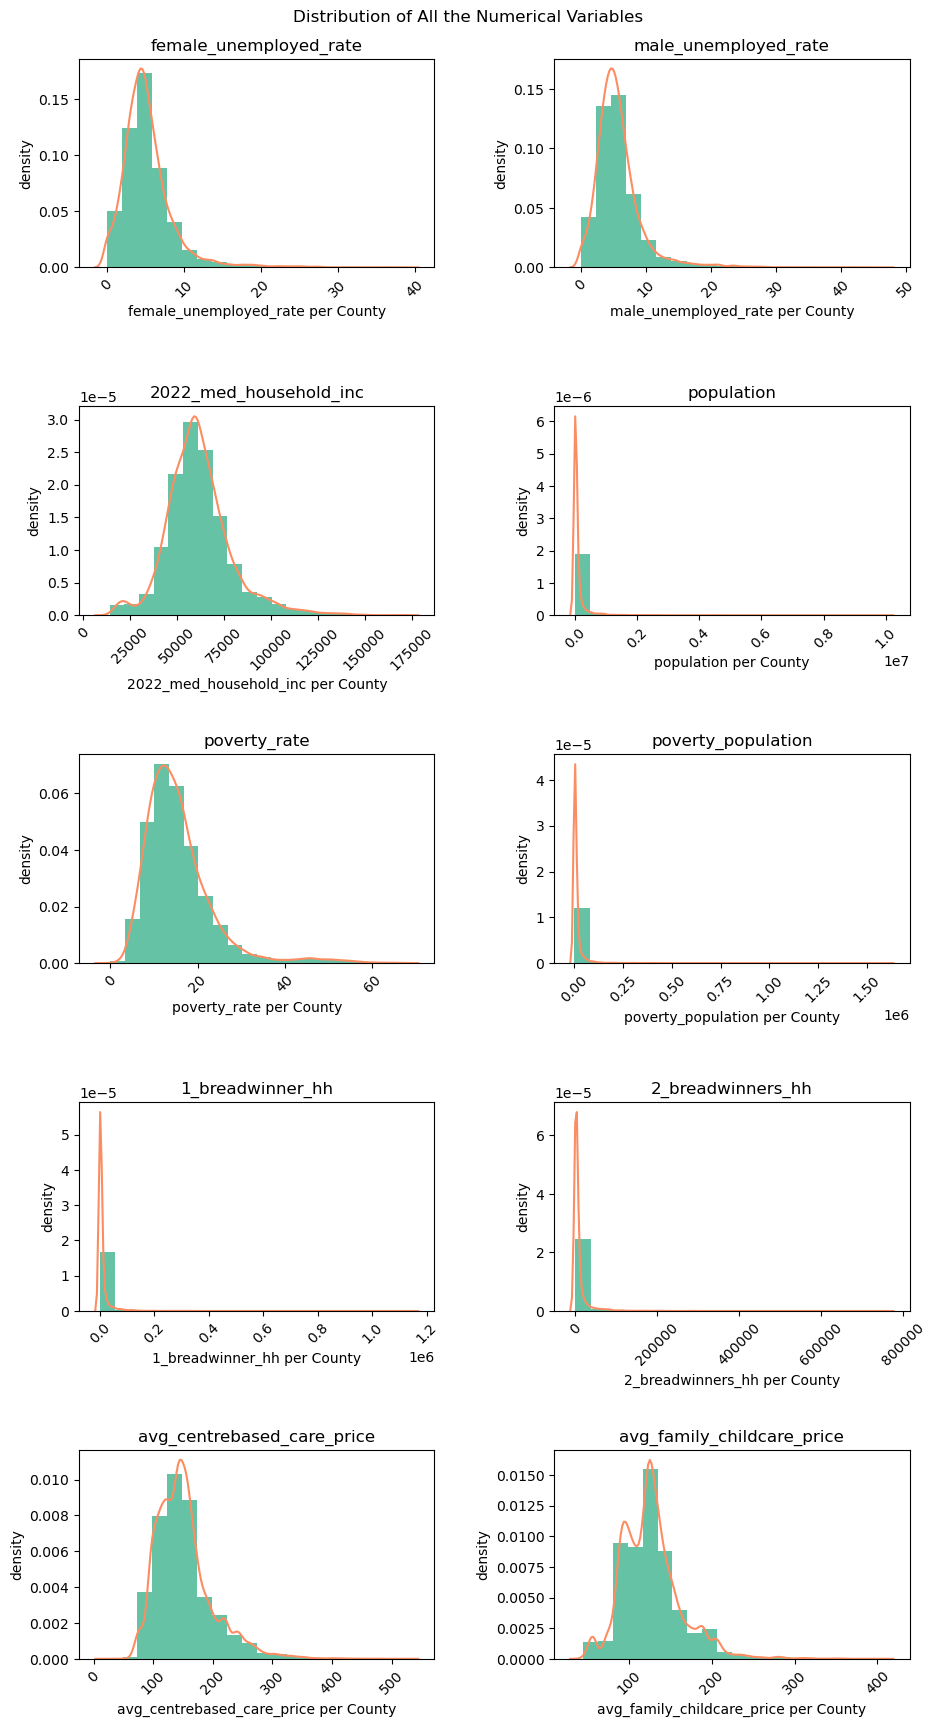

In [499]:
numeric_attr = ["female_unemployed_rate", "male_unemployed_rate", "2022_med_household_inc", "population", "poverty_rate", "poverty_population", "1_breadwinner_hh", "2_breadwinners_hh", "avg_centrebased_care_price", "avg_family_childcare_price"]
curr_col = 1
cols = 2
rows = int(len(numeric_attr)/cols)
rows += 1 if rows * cols < len(numeric_attr) else rows #if the number of rows is not enough, add 1 to it (it means the list of plots needed is odd not even)

plt.figure(figsize=(10, 35))
for attribute in numeric_attr:
    plt.subplot(rows, cols, curr_col)
    plt.title(attribute)
    plt.hist(filtered_df[attribute], bins=20, density=True)#ploting with density instead of count
    sns.kdeplot(filtered_df[attribute])
    plt.xlabel(f"{attribute} per County")
    plt.xticks(rotation = 45)
    plt.ylabel("density")
    curr_col += 1
plt.suptitle("Distribution of All the Numerical Variables")
plt.tight_layout(pad=3)
plt.show()

From the histogram and kernel density plots above, most of the attributes have a normal distribution but are mostly positively skewed with a few having some high outliers e.g. `unemployment_rate`, `poverty_rate`, and `population` have majority of their samples being on the lesser side, while having some extreemly high outlier state counties.

### 3.3) Analysing the Correlation Between all the Variables

Analysing the relationships between the numerical variables using correlation matrix

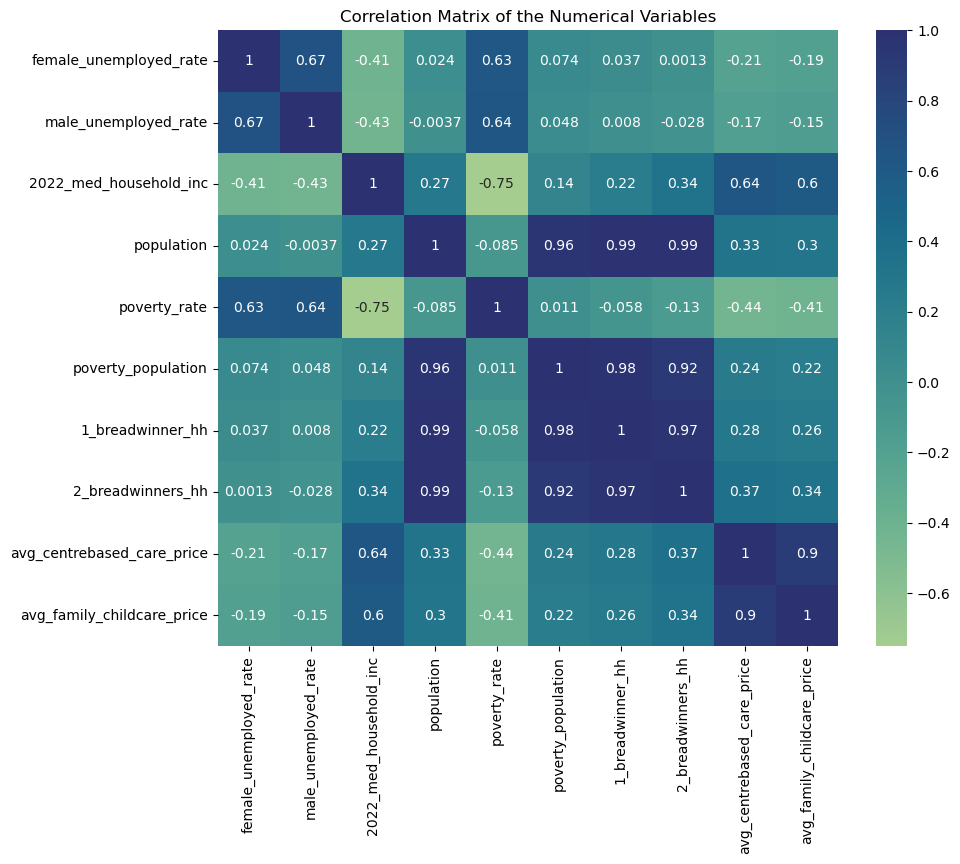

In [500]:
plt.figure(figsize=(10,8))
sns.heatmap(filtered_df[numeric_attr].corr(), cmap="crest", annot=True)
plt.title("Correlation Matrix of the Numerical Variables")
plt.show()

The correlation matrix shows that:
* Average centre-based care prices correlate with the price of family shildcare prices accross most of the state counties with 90% correlation.
* The child-care prices have around 60% correlation with the median houeshold income in each state county.
* The poverty rate in each state county is 63% correlated with the female unemployment rate and 64% correlated with the male unemployment rate.
* The poverty population has 24% correlation with centre-based care price and 22% correlation with family childcare price.
* The population size has no correlation with the unemployment rates.

### 3.4) Analysing the Unemployment Rate Variable as a Key Determinant

Checking the counties with the lowest unemployment rate

In [501]:
#Checking the counties with the lowest unemployment rate
filtered_df[filtered_df[["female_unemployed_rate","male_unemployed_rate"]].mean(axis=1) == 0][["state_name", "county_name", "female_unemployed_rate", "male_unemployed_rate"]].groupby(by=["state_name", "county_name"], as_index=False).mean()

,state_name,county_name,female_unemployed_rate,male_unemployed_rate
0,Colorado,Kiowa County,0.0,0.0
1,Hawaii,Kalawao County,0.0,0.0
2,Kansas,Greeley County,0.0,0.0
3,Kansas,Hamilton County,0.0,0.0
4,Montana,Fallon County,0.0,0.0
5,Montana,Garfield County,0.0,0.0
6,Montana,Liberty County,0.0,0.0
7,Montana,Treasure County,0.0,0.0
8,Montana,Wibaux County,0.0,0.0
9,Nebraska,Blaine County,0.0,0.0


Checking the county with the highest male unemployment rate

In [502]:
#Checking the county with the highest male unemployment rate
filtered_df[filtered_df["male_unemployed_rate"] == filtered_df["male_unemployed_rate"].max()]

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,female_unemployed_rate,male_unemployed_rate,2022_med_household_inc,population,poverty_rate,1_breadwinner_hh,2_breadwinners_hh,avg_centrebased_care_price,avg_family_childcare_price,poverty_population
15855,Puerto Rico,PR,Guanica County,72055,2020,20.3,46.5,14125,15825,66.2,1899,270,75.898189,74.169573,10476


Checking the county with the highest female unemployment rate

In [503]:
#Checking the county with the highest female unemployment rate
filtered_df[filtered_df["female_unemployed_rate"] == filtered_df["female_unemployed_rate"].max()]

,state_name,state_abbreviation,county_name,county_fips_code,studyyear,female_unemployed_rate,male_unemployed_rate,2022_med_household_inc,population,poverty_rate,1_breadwinner_hh,2_breadwinners_hh,avg_centrebased_care_price,avg_family_childcare_price,poverty_population
16070,Puerto Rico,PR,Utuado County,72141,2020,39.0,27.9,17274,28041,54.3,2956,1327,75.898189,74.169573,15226


**Viewing the anual trend of unemployment rate in the united states**

In [504]:
#extracting a subset of the dataset to use to further analyse the anual unemployment rate 
annual_unemp = filtered_df[["studyyear", "female_unemployed_rate", "male_unemployed_rate"]]
annual_unemp["mean_unemployment"] = ((annual_unemp["female_unemployed_rate"] + annual_unemp["male_unemployed_rate"])/2).round(2)
annual_unemp.head()

,studyyear,female_unemployed_rate,male_unemployed_rate,mean_unemployment
0,2018,3.4,4.9,4.15
1,2019,3.2,4.1,3.65
2,2020,2.4,3.3,2.85
3,2021,2.3,3.3,2.80
4,2022,2.6,2.9,2.75


In [505]:
#showing a summary of the average unemployment per year
annual_unemp.groupby(by = "studyyear").mean()

,female_unemployed_rate,male_unemployed_rate,mean_unemployment
studyyear,,,
2018,5.788075,6.324130,6.056102
2019,5.288385,5.825093,5.556739
2020,5.212760,5.659578,5.436169
2021,5.199224,5.704626,5.451925
2022,4.903074,5.373176,5.138125


Visualising the summary of unemployment rate per year showing the trend

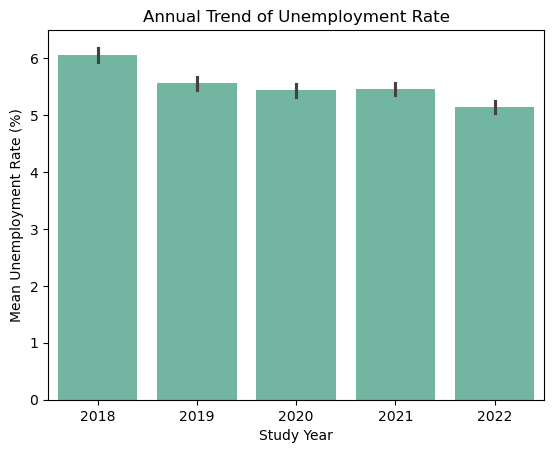

In [506]:
sns.barplot(data=annual_unemp, x="studyyear", y="mean_unemployment")
plt.title("Annual Trend of Unemployment Rate")
plt.xlabel("Study Year")
plt.ylabel("Mean Unemployment Rate (%)")
plt.show()

The bar chart above shows a gradual decrease in the annual unemployment rate in the United States from 2018 to 2022. The lowest being 2022 with unemployment rate of 5.13%

**For each gender, visualising the average unemployment rate for both genders**

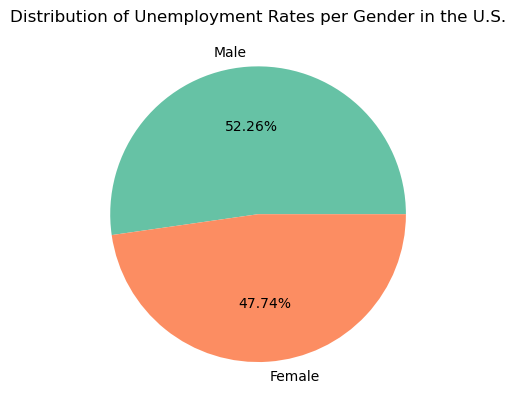

In [507]:
unemployent_rate_male = annual_unemp["male_unemployed_rate"].mean() #this is of 100%
unemployent_rate_female = annual_unemp["female_unemployed_rate"].mean() #this is of 100%

plt.pie([unemployent_rate_male, unemployent_rate_female], labels=["Male", "Female"], autopct="%.2f%%")
plt.title("Distribution of Unemployment Rates per Gender in the U.S.")
plt.show()

__Insights summary:__
* About 35 counties are recorded to have a 0% unemployment rate.
* The Guanica County has the highest male unemployment rate of 46.5% and the Utuado County has the highest female unemployment rate of 39% in 2020. Both counties are in Puerto Rico.
* Nationally, there was a gradual decrease in the annual unemployment rate in the United States from 2018 to 2022. The lowest being 2022 with unemployment rate of 5.13%.
* The piechart shows that males have higher unemployment rate than females in the United States. 52.26% and 47.74% respectively.

### 3.5) Analysing the relationships between the other variables with high correlation scores

__Visulalising a some of the variables that show correlation for each State County__

1) centre-based care prices against family child-care prices

In [508]:
def visualiseReationship(x, y, xlabel, ylabel, data_label = None, max_annot_text = "", marker = ".", transparent = False, size = 20):
    #scale the variables around their mean
    x_norm = (x - x.min()) / (x.max() - x.min()) #normalise the values of x
    y_norm = (y - y.min()) / (y.max() - y.min()) #normalise the values of y
    opacity = 1 if transparent == False else 0.6
    
    plt.scatter(x_norm, y_norm, marker=marker, label=data_label, alpha=opacity, s=size)
    
    if max_annot_text:
        plt.annotate(max_annot_text, xy = (x_norm.max()+0.03, y_norm.max()-0.01), bbox=dict(boxstyle="round", fc=(1.0, 0.7, 0.7), ec="none"))
    plt.xlabel(f"{xlabel} (Normalised)")
    plt.ylabel(f"{ylabel} (Normalised)")

In [509]:
def visualiseReationshipKDE(x, y, xlabel, ylabel, max_annot_text = "", color = None):
    #scale the variables around their mean
    x_norm = (x - x.min()) / (x.max() - x.min()) #normalise the values of x
    y_norm = (y - y.min()) / (y.max() - y.min()) #normalise the values of y

    sns.kdeplot(x = x_norm, y = y_norm, fill=True, color=color)

    if max_annot_text:
        plt.annotate(max_annot_text, xy = (x_norm.max()+0.03, y_norm.max()-0.01), bbox=dict(boxstyle="round", fc=(1.0, 0.7, 0.7), ec="none"))
    plt.xlabel(f"{xlabel} (Normalised)")
    plt.ylabel(f"{ylabel} (Normalised)")

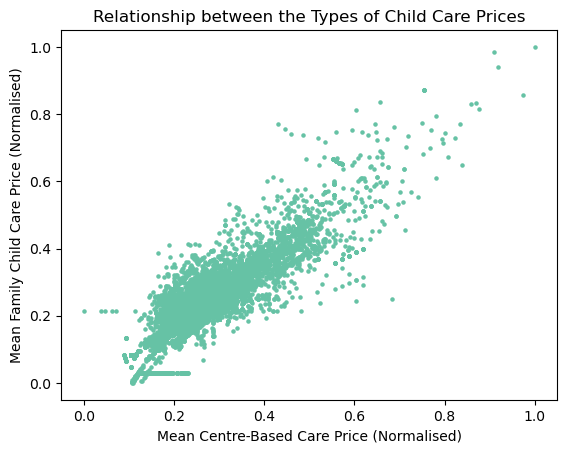

In [510]:
visualiseReationship(filtered_df["avg_centrebased_care_price"], filtered_df["avg_family_childcare_price"], xlabel="Mean Centre-Based Care Price", ylabel="Mean Family Child Care Price")
plt.title("Relationship between the Types of Child Care Prices")
plt.show()

Mean Centre-Based Care price and the Family Child-Care price are proportional to each-other, hence, there is a linear relationship between the two. An increase in one mostly lead to an increase in the other.

2. Relationship Between the 2022 Median Household Income and Child-Care Price

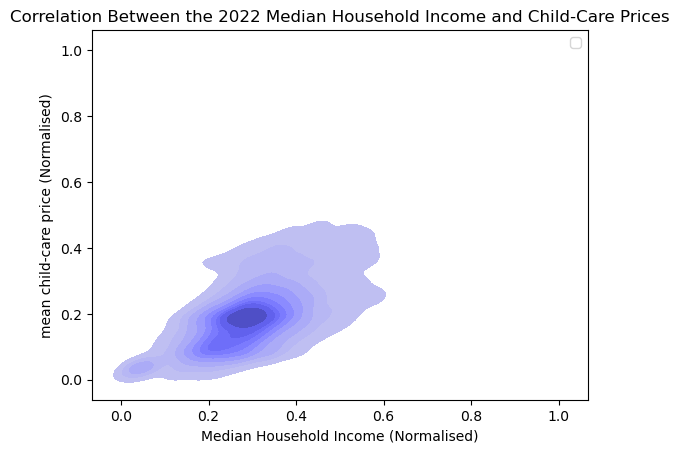

In [511]:
avg_chilcare_price_series = (filtered_df[["avg_centrebased_care_price","avg_family_childcare_price"]]).mean(axis=1)
visualiseReationshipKDE(x = filtered_df["2022_med_household_inc"], y = avg_chilcare_price_series, xlabel="Median Household Income", ylabel="mean child-care price", color = "blue")
plt.title("Correlation Between the 2022 Median Household Income and Child-Care Prices")
plt.legend()
plt.show()

The two dimensional Kernel Density Estimation (KDE) plot visualisation shows a linear relationship between Median Household Income and Mean Child-Care Price in each County.

3. Visualising the relationship between __Poverty Population__ and __Average Child-Care Prices__ in each county

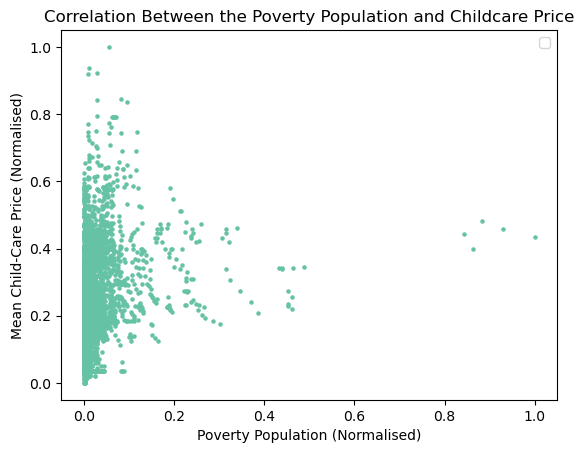

In [512]:
visualiseReationship(x = filtered_df["poverty_population"], y = avg_chilcare_price_series, xlabel="Poverty Population", ylabel="Mean Child-Care Price")
plt.title("Correlation Between the Poverty Population and Childcare Price")
plt.legend()
plt.show()

As seen above, the majority of the State Counties have poverty population on the lower end except some outliers and the relationship between the poverty population and the child-care price does not appear to have a linear shape as there is high variation of prices across the State Counties.

## 4.0) In-Depth Multivariate Data Analysis

**Primary Objectives of this Section**
1.	Analyse the trend of average U.S unemployment rate by gender against the annual poverty rate across the years from 2018 to 2022.
2.	Analyse the relationship between unemployment rate and poverty rate per gender per state.
3.	Create choropleth visualisation of median household income and poverty rate across states.
4.	Analyse the effects of proportion of households with only one working parent on the poverty rate in the states.
5.	Analyse the relationship between average weekly child-care costs and poverty rates across states.

### 4.1) Analysing the Trend of Average U.S Unemployment Rate by Gender Against the Annual Poverty Rate Across the Years from 2018 to 2022

Firstly, summarising the unemployment rate and poverty rate per gender per year

In [513]:
mean_annual_unemp_rate = filtered_df[["studyyear", "male_unemployed_rate", "female_unemployed_rate"]].groupby("studyyear", as_index=False).mean()
mean_annual_unemp_rate = mean_annual_unemp_rate.rename({ #renaming this coulmn so the data label comes out clearer on the chart
    "studyyear": "Study Year",
    "male_unemployed_rate": "male unemployment rate",
    "female_unemployed_rate": "female unemployment rate"
}, axis=1)

#convert the table from wide table to long table such that there will be a new column containing the Gender and the second column being their corresponding unemployment rate values for each year
mean_annual_unemp_rate = mean_annual_unemp_rate.melt(id_vars="Study Year", var_name="Gender", value_name="Unemployment Rate") 
mean_annual_unemp_rate.head()

,Study Year,Gender,Unemployment Rate
0,2018,male unemployment rate,6.324130
1,2019,male unemployment rate,5.825093
2,2020,male unemployment rate,5.659578
3,2021,male unemployment rate,5.704626
4,2022,male unemployment rate,5.373176


Seperating the male and female annual average unemployment rates into seperate dataframes for easier visualisation with multiple bar chart

In [514]:
#seperating the male and female unemployment rates into seperate dataframes
male_annual_uemp_rate = mean_annual_unemp_rate[mean_annual_unemp_rate["Gender"] == "male unemployment rate"]
female_annual_uemp_rate = mean_annual_unemp_rate[mean_annual_unemp_rate["Gender"] == "female unemployment rate"]

print("Female Unemployment Rate (Sorted by Study Year)")
female_annual_uemp_rate #previewing the female table

Female Unemployment Rate (Sorted by Study Year)


,Study Year,Gender,Unemployment Rate
5,2018,female unemployment rate,5.788075
6,2019,female unemployment rate,5.288385
7,2020,female unemployment rate,5.212760
8,2021,female unemployment rate,5.199224
9,2022,female unemployment rate,4.903074


Aggregating the poverty rate per year

In [515]:
#first aggregating the total population and total poverty population per year
annual_aggregate_df = filtered_df[["studyyear","population", "poverty_population"]].groupby("studyyear", as_index=False).sum()

#calculating the annual poverty rate
annual_aggregate_df["poverty_rate(%)"] = ((annual_aggregate_df["poverty_population"] / annual_aggregate_df["population"]) * 100).round(2)
annual_aggregate_df.head()

,studyyear,population,poverty_population,poverty_rate(%)
0,2018,326289971,46967586,14.39
1,2019,328016242,45136179,13.76
2,2020,329824950,43443082,13.17
3,2021,333036755,43156876,12.96
4,2022,334384595,42961345,12.85


Analysing the year-on-year rate of change of the unemployment rate and poverty rate

In [516]:
print("The year-on-year difference in male unemployment rate in the US from 2018 to 2022 is: ", end="")
print(f"{male_annual_uemp_rate.sort_values(by = "Study Year")["Unemployment Rate"].diff().mean().__round__(2)}%")

The year-on-year difference in male unemployment rate in the US from 2018 to 2022 is: -0.24%


In [517]:
print("The year-on-year difference in female unemployment rate in the US from 2018 to 2022 is: ", end="")
print(f"{female_annual_uemp_rate.sort_values(by = "Study Year")["Unemployment Rate"].diff().mean().__round__(2)}%")

The year-on-year difference in female unemployment rate in the US from 2018 to 2022 is: -0.22%


In [518]:
print("The year-on-year difference in poverty rate in the US from 2018 to 2022 is: ", end="")
print(f"{annual_aggregate_df.sort_values(by = "studyyear")["poverty_rate(%)"].diff().mean().__round__(2)}%")

The year-on-year difference in poverty rate in the US from 2018 to 2022 is: -0.39%


Visualising the annual unemployment rate by gender and poverty rate to find patterns

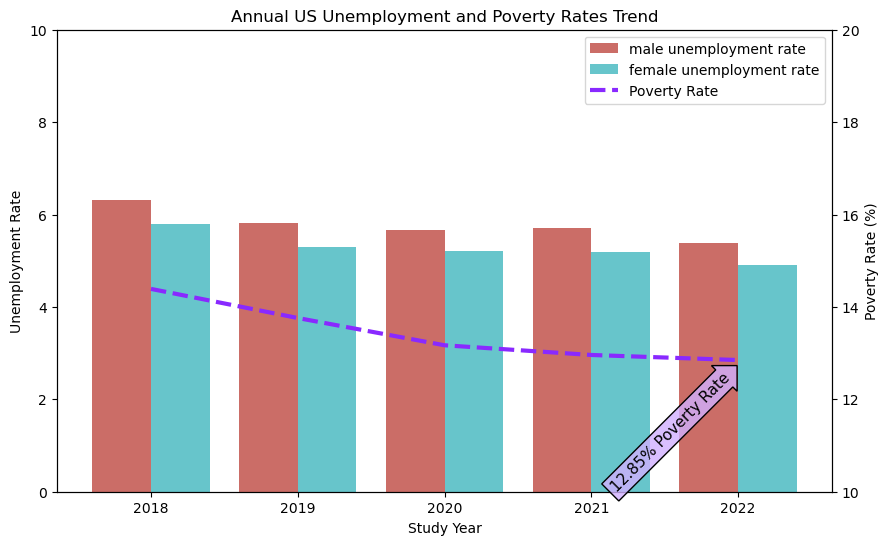

In [519]:
#Draw a grouped bar chart Visualisations to visualise the annual unemployment rate per gender
fig, ax1 = plt.subplots(figsize=(10,6))
sns.barplot(data = mean_annual_unemp_rate, x = "Study Year", y = "Unemployment Rate", hue = "Gender", ax=ax1, palette= "hls") #use seaborn to plot the line chart
ax1.set_ylim(bottom = 0, top=10)
handles1, label1 = ax1.get_legend_handles_labels()

#Plot the average poverty rate over the years
ax2 = ax1.twinx()
ax2.plot(annual_aggregate_df["poverty_rate(%)"], c = "#8929ff", linestyle = "dashed", linewidth=3.0, label = "Poverty Rate")
ax2.set_ylabel("Poverty Rate (%)")
ax2.set_ylim(bottom = 10, top = 20)
handles2, label2 = ax2.get_legend_handles_labels()

plt.text(3.54, annual_aggregate_df["poverty_rate(%)"].max() - 3.1, f"{round(annual_aggregate_df["poverty_rate(%)"].min(), 2)}% Poverty Rate",
            ha="center", va="center", rotation=45, size=11,
            bbox=dict(boxstyle="rarrow,pad=0.3",
                      fc=(0.82, 0.69, 1, 0.8), lw=1))

ax1.legend(handles= handles1 + handles2, labels= label1 + label2)
plt.title("Annual US Unemployment and Poverty Rates Trend")
plt.show()

__Insights:__  
There was a steady decline of average unemployment rate in the United States across both genders from 2018 to 2022 with a year-on-year decrease of -0.23%, the poverty rate also had a yearly decline rate with almost the same magnitude with a year-on-year decrease of -0.39%. The lowest being 2022 that has poverty rate of 12.85%, male unemployment rate of 5.3% and female unemployment rate is 4.9%.
The visualisation above showed a correlation in the trends of poverty rate and unemployment rate over the years.

### 4.2) Analysing the Relationship Between Unemployment Rate and Poverty Rate per Gender per State

**Aggregating the 2022 State-Level Data for Further Analaysis**  
Since the next couple of objectives are state-level analysis, the state-level dataset will be generated by aggregating the data from the dataset grouping by States.

In [520]:
#drop some columns which does not need not be aggregated using the mean and group the rest by the state name and other variables using the mean 
states_data = filtered_df.drop(["population", "poverty_population", "poverty_rate", "county_name","county_fips_code","1_breadwinner_hh","2_breadwinners_hh"], axis=1).groupby(["state_name","state_abbreviation"], as_index=False).mean()
#aggregate the States population, poverty population and the breadwinner-type variables by summing each of them
states_populations = filtered_df[["state_name","population", "poverty_population", "1_breadwinner_hh","2_breadwinners_hh"]].groupby("state_name", as_index=False).sum()
#calculating a new statistically accurate state-level poverty rate
states_populations["poverty_rate"] = ((states_populations["poverty_population"] / states_populations["population"]) * 100).round(2)

#merge the states populations dataset with the main states data
states_data = states_data.merge(states_populations, how="inner")

#doing further preprosessing on the new subset
states_data["2022_med_household_inc"] = states_data["2022_med_household_inc"].round(2) #round up the medium household income to 2 decimal places
states_data = states_data.rename({ #renaming some columns for clearer labeling in the map
    "2022_med_household_inc": "Median Household Income ($)",
    "state_name": "State Name",
    "state_abbreviation": "Abbreviation",
    "poverty_rate": "Poverty Rate (%)"
}, axis = 1)

states_data.head()

,State Name,Abbreviation,studyyear,female_unemployed_rate,male_unemployed_rate,Median Household Income ($),avg_centrebased_care_price,avg_family_childcare_price,population,poverty_population,1_breadwinner_hh,2_breadwinners_hh,Poverty Rate (%)
0,Alabama,AL,2020.00000,6.685075,6.739701,51052.31,119.086098,109.243541,24659883,4035344,2702212,1974879,16.36
1,Alaska,AK,2020.02027,7.324324,10.035135,78169.14,242.180721,204.839633,3683346,387666,407834,355065,10.52
2,Arizona,AZ,2020.00000,7.620000,7.761333,58130.81,165.818570,139.513855,35422533,5090433,4031018,2769739,14.37
3,Arkansas,AR,2020.00000,5.941867,6.296000,49349.06,103.929326,91.314389,15026892,2498796,1674378,1297763,16.63
4,California,CA,2020.00000,6.634828,7.196552,80397.23,237.930513,205.329726,196589737,25427244,21542358,17008085,12.93


**Performing the Analysis of Unemployment Rate per Gender per State**

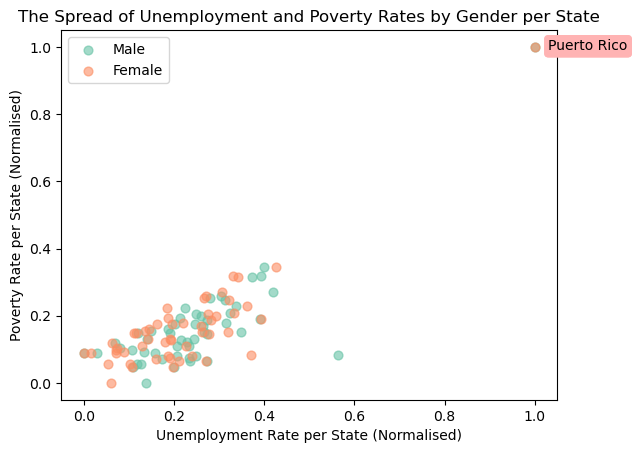

In [521]:
male_data = states_data[["State Name", "Poverty Rate (%)", "male_unemployed_rate"]]
female_data = states_data[["State Name", "Poverty Rate (%)", "female_unemployed_rate"]]
m_max_annotate_text = male_data[male_data["Poverty Rate (%)"] == male_data["Poverty Rate (%)"].max()]["State Name"].iloc[0] #to show the name of the state with the highest level of unemployment rate to poverty rate
f_max_annotate_text = female_data[female_data["Poverty Rate (%)"] == female_data["Poverty Rate (%)"].max()]["State Name"].iloc[0] #to show the name of the state with the highest level of unemployment rate to poverty rate

visualiseReationship(male_data["male_unemployed_rate"], male_data["Poverty Rate (%)"], data_label="Male", ylabel="Poverty Rate per State", xlabel="Unemployment Rate per State", max_annot_text = m_max_annotate_text,  marker="o", transparent=True, size = 40)
visualiseReationship(female_data["female_unemployed_rate"], female_data["Poverty Rate (%)"], data_label="Female", ylabel="Poverty Rate per State", xlabel="Unemployment Rate per State", max_annot_text = m_max_annotate_text, marker="o", transparent=True, size = 40)
plt.title("The Spread of Unemployment and Poverty Rates by Gender per State")
plt.legend()
plt.show()

Showing the details of the top 5 States with the highest Unemployment Rate

In [522]:
states_data["avg_unemployment_rate"] = ((male_data["male_unemployed_rate"] + female_data["female_unemployed_rate"])/2).round(2) #get the average unemployment rate from the two genders
states_data[["State Name", "avg_unemployment_rate"]].sort_values(by = "avg_unemployment_rate", ascending=False).head()

,State Name,avg_unemployment_rate
39,Puerto Rico,15.81
1,Alaska,8.68
24,Mississippi,7.98
2,Arizona,7.69
49,West Virginia,7.30


Showing the details of the top 5 States with the highest Poverty Rate

In [523]:
states_data[["State Name", "Poverty Rate (%)"]].sort_values(by = "Poverty Rate (%)", ascending=False).head()

,State Name,Poverty Rate (%)
39,Puerto Rico,43.38
24,Mississippi,19.93
18,Louisiana,19.00
31,New Mexico,18.87
49,West Virginia,17.23


__Insights:__  
Down to the States level, the scatter plot further shows the spread and the general linear relationship between unemployment rate and poverty rates  in all the States. The analysis also spotlights the State of Puerto Rico which has the highest unemployment and poverty rate in the United State, 15.81% and 43.38% respectively.

### 4.3) Creating Interactive Choropleth Visualisation of Median Household Income and Poverty Rate Across States

Visualising using an interractive Pyplot choropleth to show the `States`, the `Median Household Income` and `Poverty Rates`. The Pyplot figure will be drawn using shape-points GeoJSON data of US States publically available and downloaded from https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json

In [524]:
import json

#importing the full USA states GeoJSON shape data, this will enable Plotly render the shapes of all the states including Puerto-Rico
with open("./dataset/us-states.geojson", "r") as gj:
    geojson_data = json.load(gj)

__Adding GeoLocation Centroids (Lon/Lat) to the States Dataset__  
Using the US States' longitude and latitude centroids dataset publically available at https://developers.google.com/public-data/docs/canonical/states_csv


In [525]:
states_centroids = pd.read_csv("./dataset/us-states-lon-lat-centroids.csv") #importing the downloaded centroids data
states_centroids.head()

,state_abr,latitude,longitude,state_name
0,AK,63.588753,-154.493062,Alaska
1,AL,32.318231,-86.902298,Alabama
2,AR,35.201050,-91.831833,Arkansas
3,AZ,34.048928,-111.093731,Arizona
4,CA,36.778261,-119.417932,California


In [526]:
#merging the centroid geo-location data into the states dataset
states_data_and_loc = states_data.merge(states_centroids, left_on="Abbreviation", right_on="state_abr")
states_data_and_loc = states_data_and_loc.drop(["state_abr", "state_name"], axis = 1) #drop the duplicate columns
states_data_and_loc.head()

,State Name,Abbreviation,studyyear,female_unemployed_rate,male_unemployed_rate,Median Household Income ($),avg_centrebased_care_price,avg_family_childcare_price,population,poverty_population,1_breadwinner_hh,2_breadwinners_hh,Poverty Rate (%),avg_unemployment_rate,latitude,longitude
0,Alabama,AL,2020.00000,6.685075,6.739701,51052.31,119.086098,109.243541,24659883,4035344,2702212,1974879,16.36,6.71,32.318231,-86.902298
1,Alaska,AK,2020.02027,7.324324,10.035135,78169.14,242.180721,204.839633,3683346,387666,407834,355065,10.52,8.68,63.588753,-154.493062
2,Arizona,AZ,2020.00000,7.620000,7.761333,58130.81,165.818570,139.513855,35422533,5090433,4031018,2769739,14.37,7.69,34.048928,-111.093731
3,Arkansas,AR,2020.00000,5.941867,6.296000,49349.06,103.929326,91.314389,15026892,2498796,1674378,1297763,16.63,6.12,35.201050,-91.831833
4,California,CA,2020.00000,6.634828,7.196552,80397.23,237.930513,205.329726,196589737,25427244,21542358,17008085,12.93,6.92,36.778261,-119.417932


**Visualising the Median Household Income and Poverty Rate per State using Choropleth**

In [527]:
# plot choropleth with Plotly
fig = go.Figure()

fig.add_trace(go.Choropleth(
    geojson=geojson_data,
    featureidkey="properties.name",
    locations=states_data_and_loc["State Name"],
    z=states_data_and_loc["Median Household Income ($)"],
    colorscale="Viridis",
    name="Household Income",
    # hovertext=states_data_and_loc["State Name"],
    colorbar=dict(
        title="MHI",
        x=0.85
    )
))

# plotting the poverty rate per state using a bubble marker on the choropleth
fig.add_trace(go.Scattergeo(
    lon=states_data_and_loc["longitude"],
    lat=states_data_and_loc["latitude"],
    text=states_data_and_loc["State Name"] + "<br>Poverty Rate: " + states_data_and_loc["Poverty Rate (%)"].astype(str) +"%<br>Median Houshold Income: $" + states_data_and_loc["Median Household Income ($)"].astype(str),
    mode="markers",
    marker=dict(
        size=states_data_and_loc["Poverty Rate (%)"],
        color="red",
        opacity=0.5,
        line=dict(width=1, color="white")
    ),
    name="2022 Poverty Rate"
))

#drawing the bubble chart's legend
legend_bubble_sizes = [5, 10, 20] 
for s in legend_bubble_sizes:
    fig.add_trace(go.Scattergeo(
        lon=[None],
        lat=[None],
        mode="markers",
        marker=dict(
            size= s,
            color="red",
            opacity=0.5
        ),
        name=f"{s}%"
))
#-------------------

fig.update_geos(
    fitbounds="locations", #fit the chart to view all locations
    projection_type="mercator", #the map was looking stretched so this makes it appear similar to how maps are drawn generally
)

fig.update_layout(
    width=1000,
    height=700,
    margin=dict(l=20, r=20, t=50, b=20),
    legend=dict( #move the bubbles legend to the left
        x=0.17,
        y=0.98,
        bgcolor="rgba(255,255,255,0.6)"
    ),
    title=dict(
        text = "Interactive Choropleth of US Median Household Income (MHI) & Poverty Rate by State",
        x = 0.1
    )
)

fig.show()

**INSIGHTS:**
* The combined interactive choropleth and bubble map visualisation above, shows the spread of the median household income across the states and compares them with their poverty rates. 
* From the visualisation, it is observed that many of the southern States in the US have averagely lower median household income compared to the other regions. It also showed that the southern states averagely have higher poverty rates than other regions.
* The States with the highest median household income are in the eastern region towards the shores of the Country.
* The visualisation emphasises the extreme outlier in the south; the __State of Puerto Rico__ with the highest poverty rate of 43.38% and the lowest median household income of $22,524.21 in the country.

### 4.4) Analysing the Proportion of one-breadwinner households (with kids below 18 years) and the impact on the States' poverty rates

Calculating the ratio of the two classes of households (between one bread winner and two bread winners households)

In [528]:
household_ratio_data = pd.DataFrame(states_data["State Name"])
household_ratio_data["ratio_1_breadwinner_hh(%)"] = ((states_data["1_breadwinner_hh"] / states_data[["1_breadwinner_hh", "2_breadwinners_hh"]].sum(axis=1)) *100).round(2)
household_ratio_data.head()#checking the resulting dataset

,State Name,ratio_1_breadwinner_hh(%)
0,Alabama,57.78
1,Alaska,53.46
2,Arizona,59.27
3,Arkansas,56.34
4,California,55.88


A) Households with Only Father Working

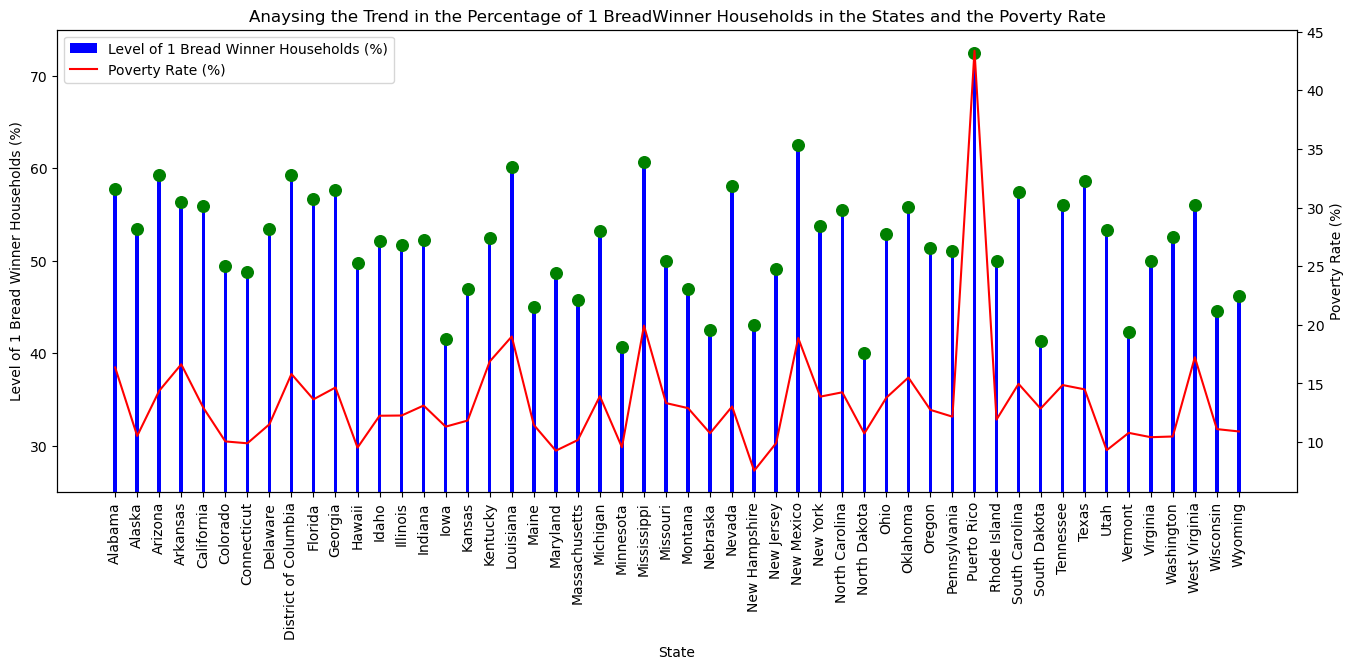

In [529]:
fig, ax1 = plt.subplots(figsize=(16,6))
ax1.bar(x = states_data["State Name"], height= household_ratio_data["ratio_1_breadwinner_hh(%)"], width=0.16, color="blue", label="Level of 1 Bread Winner Households (%)")
ax1.scatter(x = states_data["State Name"], y = household_ratio_data["ratio_1_breadwinner_hh(%)"], s=70, c="green")
ax1.set_ylim(bottom=25, top=75)
ax1.set_xlabel("State")
ax1.set_ylabel("Level of 1 Bread Winner Households (%)")
handles1, label1 = ax1.get_legend_handles_labels()

plt.xticks(rotation = 90)

ax2 = ax1.twinx()
ax2.plot(states_data["Poverty Rate (%)"], color="red", label="Poverty Rate (%)")
ax2.set_ylabel("Poverty Rate (%)")
handles2, label2 = ax2.get_legend_handles_labels()

ax1.legend(handles= handles1 + handles2, labels= label1 + label2, loc="best")
plt.title("Anaysing the Trend in the Percentage of 1 BreadWinner Households in the States and the Poverty Rate")
plt.show()

**INSIGHTS:**  
The visualisation above shows a trend of poverty rates being proportional to the rate of one-breadwinner households in the States. Especially in Puerto-Rico where over 70% of households raising kids below the age of 18 has only one working parent.

### 4.5) Analysing effects of the States' average weekly child-care cost on the poverty rate

In [530]:
states_childcare_cost_df = states_data[["State Name", "avg_centrebased_care_price", "avg_family_childcare_price", "Poverty Rate (%)"]]
states_childcare_cost_df["avg_child_care_price"] = states_childcare_cost_df[["avg_centrebased_care_price", "avg_family_childcare_price"]].mean(axis = 1).round(2)
states_childcare_cost_df.head()

,State Name,avg_centrebased_care_price,avg_family_childcare_price,Poverty Rate (%),avg_child_care_price
0,Alabama,119.086098,109.243541,16.36,114.16
1,Alaska,242.180721,204.839633,10.52,223.51
2,Arizona,165.818570,139.513855,14.37,152.67
3,Arkansas,103.929326,91.314389,16.63,97.62
4,California,237.930513,205.329726,12.93,221.63


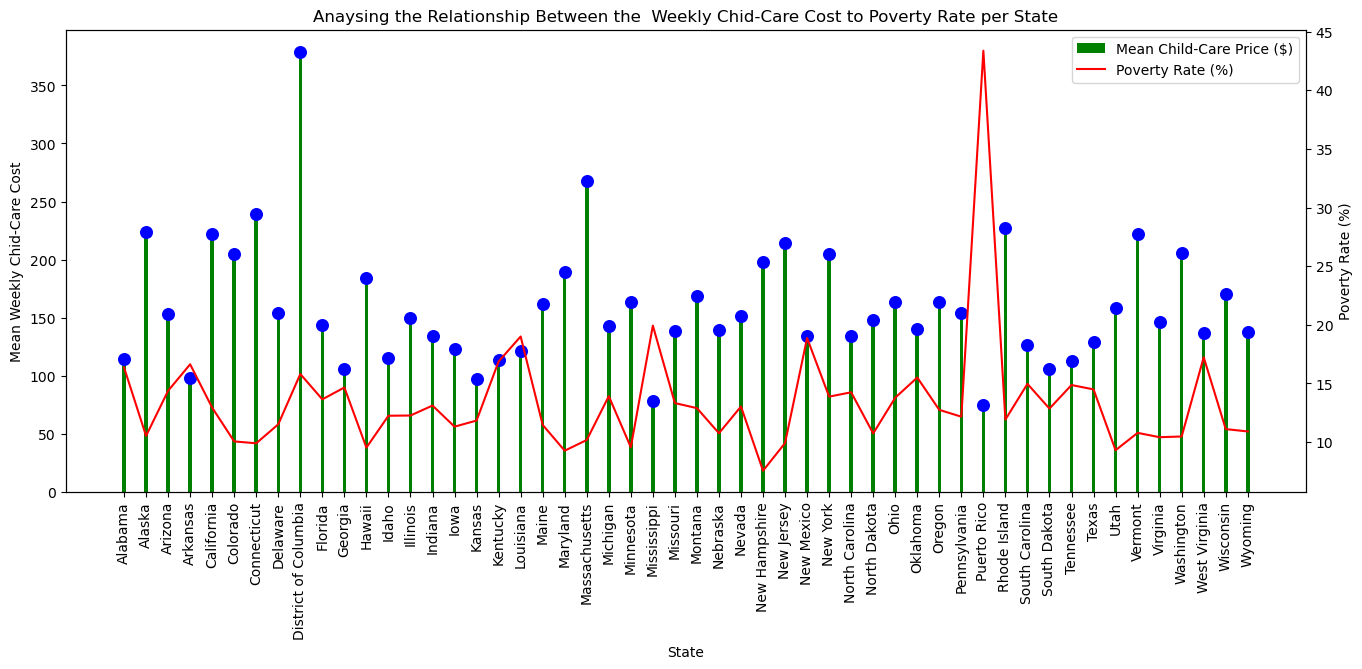

In [531]:
fig, ax1 = plt.subplots(figsize=(16,6))
ax1.bar(x = states_childcare_cost_df["State Name"], height= states_childcare_cost_df["avg_child_care_price"], width=0.16, color="green", label="Mean Child-Care Price ($)")
ax1.scatter(x = states_childcare_cost_df["State Name"], y = states_childcare_cost_df["avg_child_care_price"], s=70, c="blue")
plt.xticks(rotation = 90)
# ax1.set_ylim(bottom=35, top=75)
ax1.set_xlabel("State")
ax1.set_ylabel("Mean Weekly Chid-Care Cost")
handles1, label1 = ax1.get_legend_handles_labels()

ax2 = ax1.twinx()
ax2.plot(states_childcare_cost_df["Poverty Rate (%)"], color="red", label="Poverty Rate (%)")
ax2.set_ylabel("Poverty Rate (%)")
handles2, label2 = ax2.get_legend_handles_labels()

ax1.legend(handles= handles1 + handles2, labels= label1 + label2, loc="best")
plt.title("Anaysing the Relationship Between the  Weekly Chid-Care Cost to Poverty Rate per State")
plt.show()

Analysing the States with the highest and lowest weekly child-care cost

In [532]:
#showing the States with the highest child-care cost
states_childcare_cost_df.sort_values(by="avg_child_care_price", ascending=False).head(3)

,State Name,avg_centrebased_care_price,avg_family_childcare_price,Poverty Rate (%),avg_child_care_price
8,District of Columbia,400.777273,357.290909,15.80,379.03
21,Massachusetts,304.758078,229.799221,10.17,267.28
6,Connecticut,271.272727,207.852273,9.89,239.56


In [533]:
#showing the States with the lowest child-care cost
states_childcare_cost_df.sort_values(by="avg_child_care_price", ascending=True).head(3)

,State Name,avg_centrebased_care_price,avg_family_childcare_price,Poverty Rate (%),avg_child_care_price
39,Puerto Rico,75.898189,74.169573,43.38,75.03
24,Mississippi,100.971162,55.417129,19.93,78.19
16,Kansas,104.978978,89.282424,11.83,97.13


**INSIGHTS:**

The chart above shows a very slight negative correlation trend between the average cost of child-care and the poverty rates in the States. The State with the highest weekly child-care cost of $379.03 was the __District of Columbia__ but the poverty rate is 15.8% which is the national average. While the state with the lowest child-care cost is Puerto-Rico with an average child-care cost of $75.03 but has the highest poverty rate in the country.

## 5.0) General Conclusions Based on the Outcomes

The result of this analysis shows the true view of the wealth disparity in a first-world country like the United States of America. The results suggests that nation-wide averages of key socio-economic variables may not be fully representative of the realities within the Counties and the States in the US.

Considering the insights gained from this analysis, the following conclusions and recommendations are presented:
- There is a positive correlation between unemployment rate and poverty rate in the States, more Government initiatives for job creation may further help improve the socio-economic state in many regions in the US and reduce the poverty rate.
- The large income and poverty-rate gaps between the State of Puerto-Rico and other States may suggest an existence of low prioritisation in resource allocation and economic development planning for that state.
- Reforms in Government resource allocation may lead to better wealth distribution among the States, especially for States in the Southern region and most especially for the State of Puerto-Rico.
- Public awareness campaigns on dual-earner households could help reduce poverty levels in States that typically have households relying on one breadwinner.
